In [2]:
import numpy as np
import pandas as pd

Auto = pd.read_csv('Auto.csv')

In [3]:
Auto.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [4]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


(a)

In [6]:
mpg_median = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > mpg_median).astype(int)

Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,1
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,1
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,1
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,1


(b)

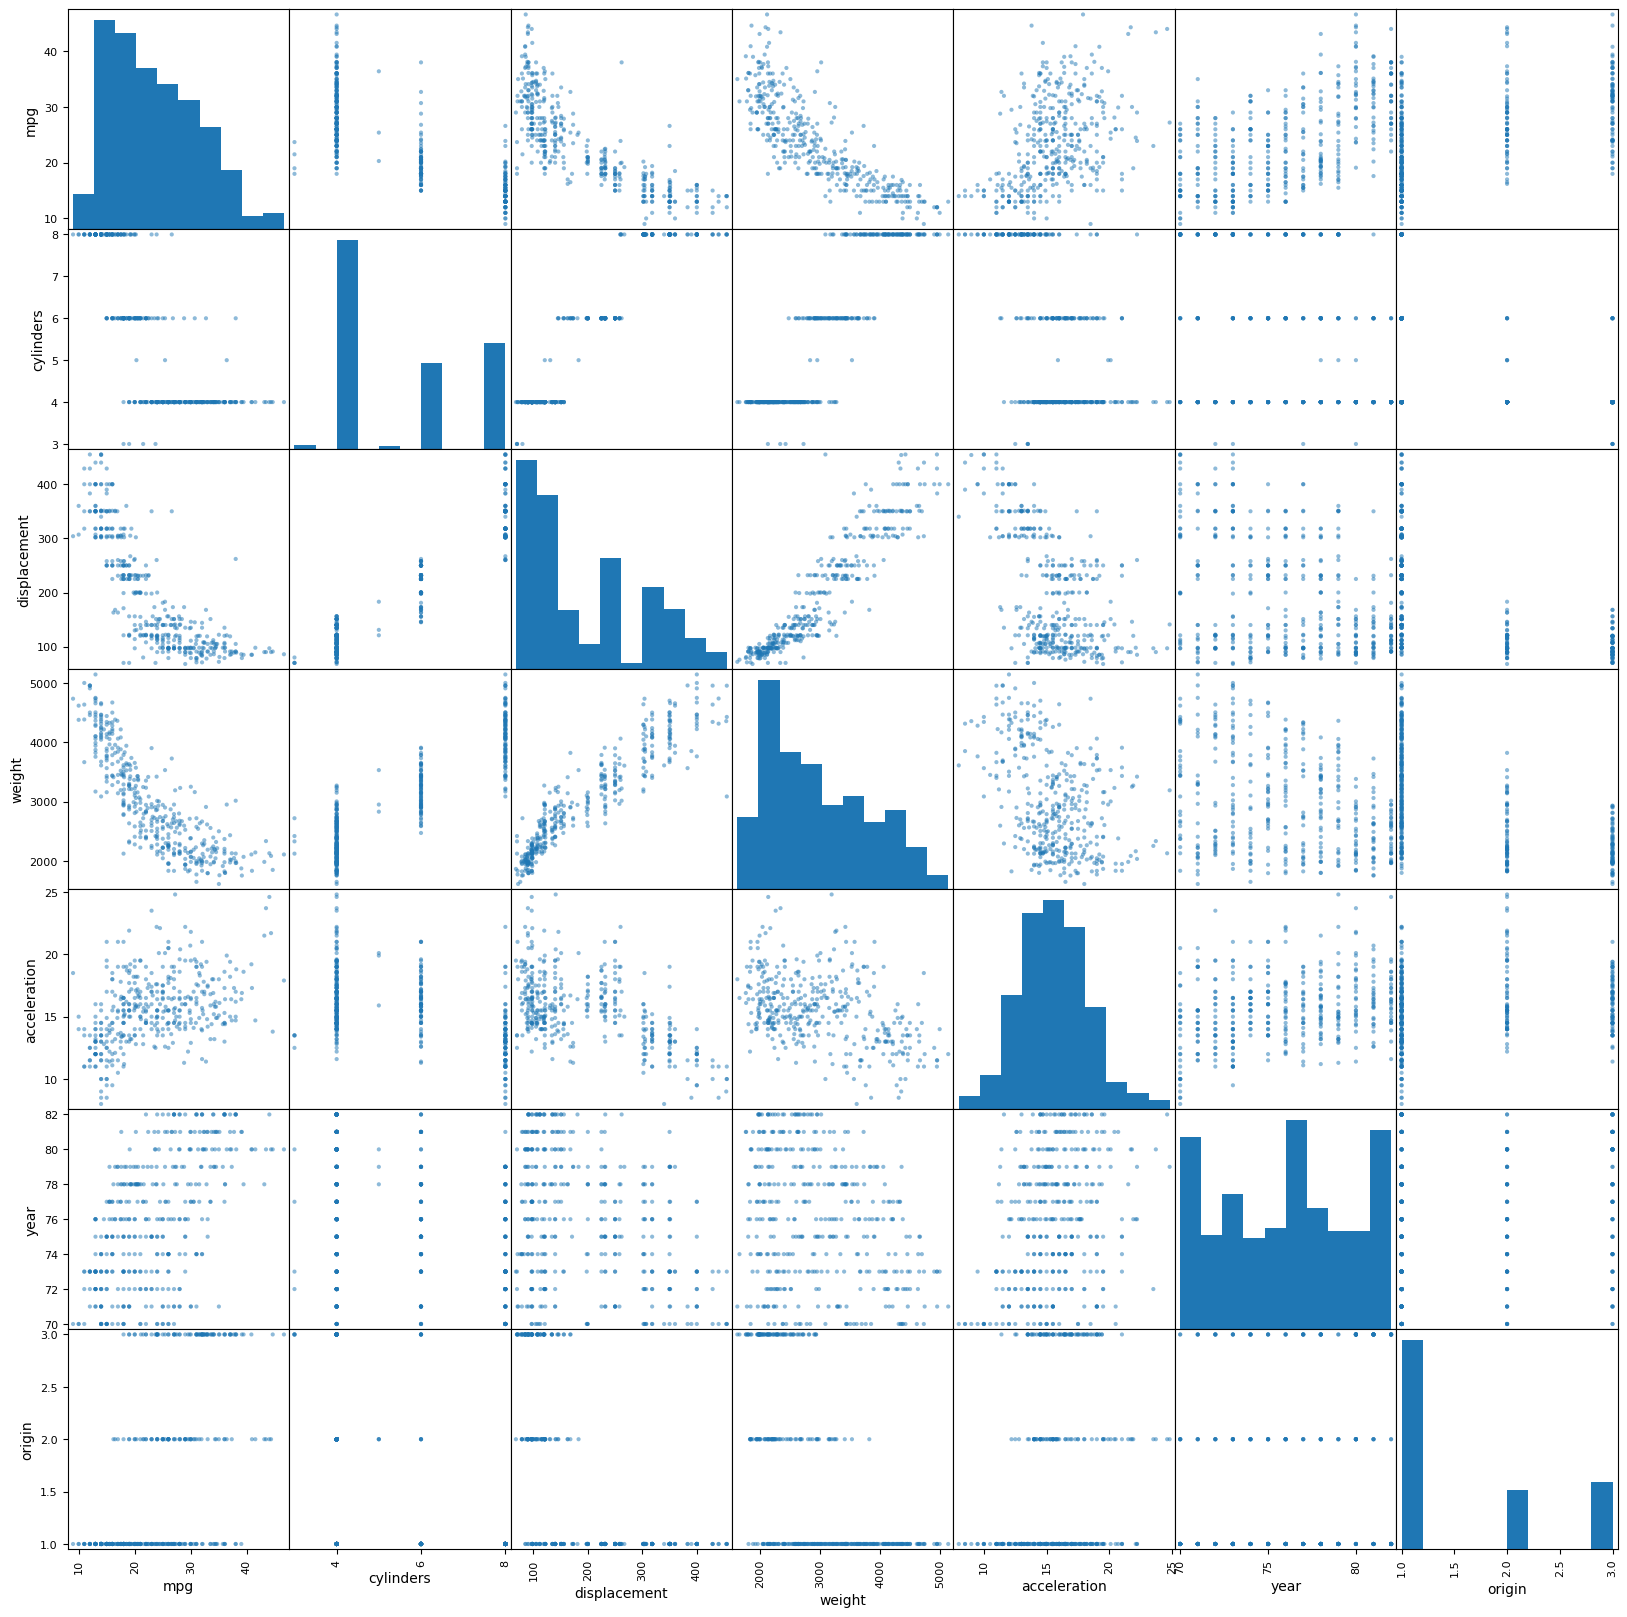

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

pd.plotting.scatter_matrix(data, figsize=(20, 20))
plt.show()

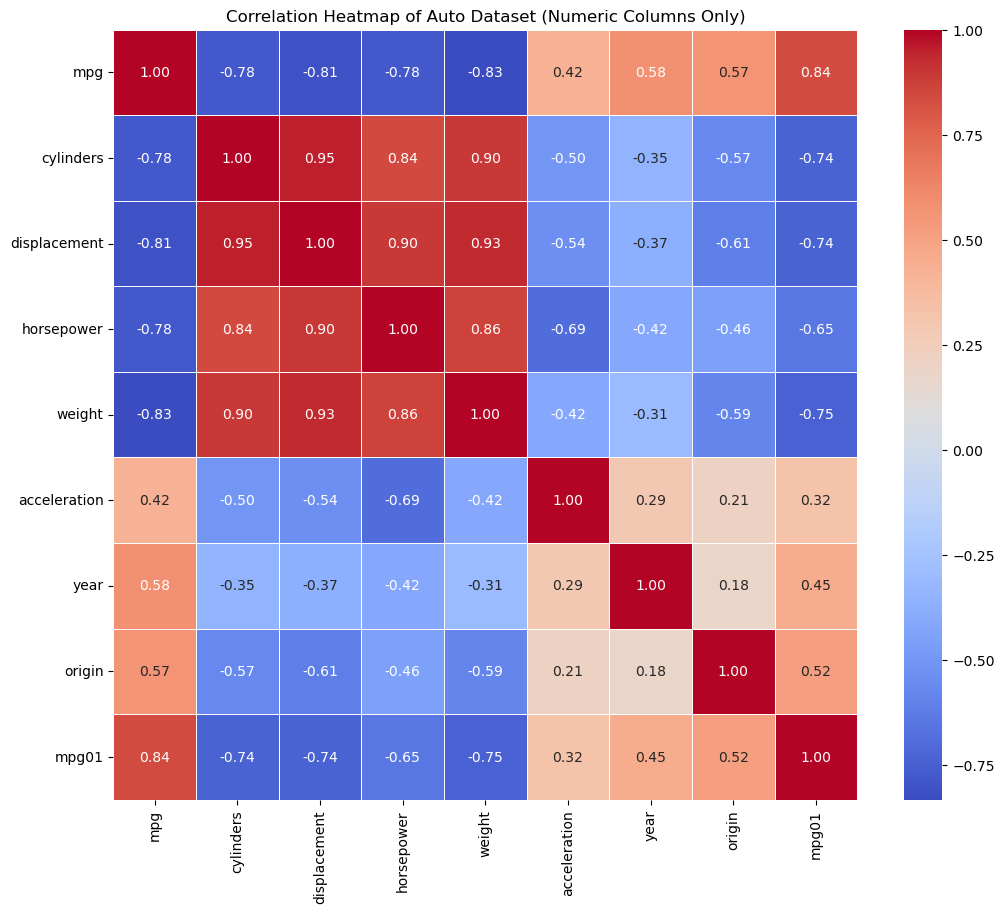

In [23]:
Auto = Auto.replace('?', np.nan)
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna()  

numeric_Auto = Auto.select_dtypes(include=[np.number])
correlation_matrix = numeric_Auto.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Auto Dataset (Numeric Columns Only)")
plt.show()

(c)

In [24]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

X = Auto[features]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("訓練集筆數:", X_train.shape[0])
print("測試集筆數:", X_test.shape[0])

訓練集筆數: 274
測試集筆數: 118


(d)

In [25]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc

print("Confusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.3f}")
print(f"Test Error: {test_error:.3f}")

Confusion Matrix:
 [[51 15]
 [ 0 52]]

Accuracy: 0.873
Test Error: 0.127


(e)

In [26]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred_qda = qda.predict(X_test)

cm_qda = confusion_matrix(y_test, y_pred_qda)
acc_qda = accuracy_score(y_test, y_pred_qda)
test_error_qda = 1 - acc_qda

print("QDA Confusion Matrix:\n", cm_qda)
print(f"\nQDA Accuracy: {acc_qda:.3f}")
print(f"QDA Test Error: {test_error_qda:.3f}")


QDA Confusion Matrix:
 [[54 12]
 [ 3 49]]

QDA Accuracy: 0.873
QDA Test Error: 0.127


(f)

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

cm_log = confusion_matrix(y_test, y_pred_log)
acc_log = accuracy_score(y_test, y_pred_log)
test_error_log = 1 - acc_log

print("Logistic Regression Confusion Matrix:\n", cm_log)
print(f"\nLogistic Regression Accuracy: {acc_log:.3f}")
print(f"Logistic Regression Test Error: {test_error_log:.3f}")

Logistic Regression Confusion Matrix:
 [[55 11]
 [ 1 51]]

Logistic Regression Accuracy: 0.898
Logistic Regression Test Error: 0.102


(g)

In [29]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

cm_nb = confusion_matrix(y_test, y_pred_nb)
acc_nb = accuracy_score(y_test, y_pred_nb)
test_error_nb = 1 - acc_nb

print("Naive Bayes Confusion Matrix:\n", cm_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.3f}")
print(f"Naive Bayes Test Error: {test_error_nb:.3f}")

Naive Bayes Confusion Matrix:
 [[52 14]
 [ 2 50]]
Naive Bayes Accuracy: 0.864
Naive Bayes Test Error: 0.136


(h)

In [30]:
from sklearn.neighbors import KNeighborsClassifier

best_k = None
best_acc = 0.0
best_cm = None

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    
    acc_k = accuracy_score(y_test, y_pred_knn)
    if acc_k > best_acc:
        best_acc = acc_k
        best_k = k
        best_cm = confusion_matrix(y_test, y_pred_knn)

print(f"\nBest K in KNN: {best_k}")
print("Best KNN Confusion Matrix:\n", best_cm)
print(f"Best KNN Accuracy: {best_acc:.3f}")
print(f"Best KNN Test Error: {1 - best_acc:.3f}")


Best K in KNN: 3
Best KNN Confusion Matrix:
 [[51 15]
 [ 2 50]]
Best KNN Accuracy: 0.856
Best KNN Test Error: 0.144
